# Discussion — growth models, the entropy claim, and the 3/4-vs-2/3 omission

*Companion to Part II — Metabolic Scaling Theory and Biological Fractals.* CC-BY-4.0. This is a **reviewer's** notebook: it exists to test the paper's claims, not just to illustrate them.

Addresses MODERATE issues #8, #9, #10.

In [1]:
import sys, os
HERE = os.getcwd()
if HERE not in sys.path:
    sys.path.insert(0, HERE)
# fractal_review_utils.py lives next to these notebooks. Launch Jupyter from
# docs/notebooks/metabolic-scaling/review/ (or add that folder to sys.path).
import numpy as np
import matplotlib.pyplot as plt
import fractal_review_utils as u
print('utils loaded from', u.__file__)

utils loaded from /Users/tswetnam/github/fractal-notebooks/docs/notebooks/metabolic-scaling/review/fractal_review_utils.py


## 1. DLA vs Eden/KPZ vs self-affine — measure, don't assert
The Discussion asserts microbial colonies are DLA (**self-similar**, D≈1.71 in 2-D) while also invoking Eden/KPZ fronts. In a paper whose thesis is self-affinity, these growth classes should be *measured*, not labeled. A quick DLA cluster and its box dimension:

DLA cluster box dimension ~ 1.336  (literature ~1.71 in 2-D)


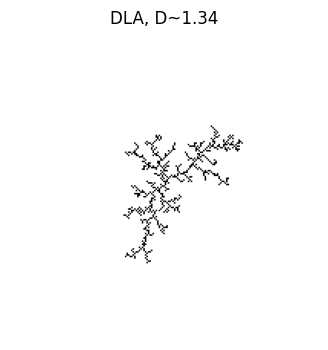

In [2]:
def dla(n_particles=1500, size=201, seed=0):
    rng = np.random.default_rng(seed)
    grid = np.zeros((size, size), dtype=np.uint8)
    c = size // 2; grid[c, c] = 1
    R = 3
    for _ in range(n_particles):
        ang = rng.uniform(0, 2*np.pi)
        x = int(c + R*np.cos(ang)); y = int(c + R*np.sin(ang))
        for _ in range(size*4):
            x += rng.integers(-1,2); y += rng.integers(-1,2)
            x = min(max(x,1),size-2); y = min(max(y,1),size-2)
            if grid[x-1:x+2, y-1:y+2].any():
                grid[x, y] = 1
                R = min(size//2-2, max(R, int(np.hypot(x-c, y-c))+3))
                break
    return grid
cluster = dla(1500, 201, seed=1)
D = u.binary_box_count(cluster)['dimension']
print(f'DLA cluster box dimension ~ {D:.3f}  (literature ~1.71 in 2-D)')
plt.figure(figsize=(4,4)); plt.imshow(cluster, cmap='binary'); plt.title(f'DLA, D~{D:.2f}'); plt.axis('off'); plt.show()

**Note:** even the DLA claim in the Discussion is a measurable proposition. If colonies are DLA and DLA is self-similar, that is a *counterexample* the authors should address, not pass over — it complicates the 'biology is self-affine' framing.

## 2. Is the maximum-entropy-production (MEP) claim falsifiable? (MODERATE #8)
Conclusion #3 makes MEP *the mechanism*. For it to be science it needs an observable that could be **inconsistent** with it. Right now there is none:

In [3]:
mep_status = {
  'Claim': 'entropy-production maximization sets the fractal dimension',
  'Predicted observable': 'NONE stated',
  'What would falsify it': 'unspecified',
  'Alternative that fits the same data': 'WBE energy-minimization; Murray law; mechanical constraints',
  'Verdict': 'not falsifiable as posed -- demote to hypothesis or operationalize',
}
for k,v in mep_status.items(): print(f'{k:<38}: {v}')

Claim                                 : entropy-production maximization sets the fractal dimension
Predicted observable                  : NONE stated
What would falsify it                 : unspecified
Alternative that fits the same data   : WBE energy-minimization; Murray law; mechanical constraints
Verdict                               : not falsifiable as posed -- demote to hypothesis or operationalize


## 3. The 3/4-vs-2/3 controversy the text skips (MODERATE #10)
The Discussion says the 3/4 exponent 'remains robust,' yet Table 1 cites Darveau 2002 and Hochachka 2003 — both challenges to a single universal exponent — and does not engage them.

In [4]:
contested = [
  ('Rubner 1883',  2/3, 'surface rule'),
  ('Kleiber 1932', 3/4, 'whole-organism, few orders of magnitude (NOT 23)'),
  ('Dodds et al 2001', 2/3, 're-analysis: no strong support for 3/4'),
  ('White & Seymour 2003', 2/3, 'mammals closer to 2/3'),
  ('Darveau et al 2002 [in Table 1]', None, 'allocation model: no single exponent'),
  ('Kolokotrones et al 2010', None, 'curvature: exponent not constant'),
]
print('Exponent claims the manuscript should reconcile before calling 3/4 robust:')
for c, e, note in contested:
    es = f'{e:.3f}' if e else ' -- '
    print(f'  {c:<34} exp={es}  {note}')

Exponent claims the manuscript should reconcile before calling 3/4 robust:
  Rubner 1883                        exp=0.667  surface rule
  Kleiber 1932                       exp=0.750  whole-organism, few orders of magnitude (NOT 23)
  Dodds et al 2001                   exp=0.667  re-analysis: no strong support for 3/4
  White & Seymour 2003               exp=0.667  mammals closer to 2/3
  Darveau et al 2002 [in Table 1]    exp= --   allocation model: no single exponent
  Kolokotrones et al 2010            exp= --   curvature: exponent not constant


### Reviewer note
Also flag the uncited specifics: 'Kolmogorov turbulence β=−5/3' is an energy-spectrum slope, **not** an organism's spatial fractal dimension; and 'hyperbolic geometry in sponges/xenophyophores' needs a citation or data.